## Exploración inicial de datos

### By: Carlos Javier Palacios Sanchez

### Date: 17/08/2026

### Description:

Requerimiento
Crear una nueva rama de git (Usar Gitflow) y Crear un notebook para la exploración inicial de los datos

Tomar como ejemplo los pasos de: https://joserzapata.github.io/post/ciencia-datos-proyecto-python/2-exploration/
el objetivo es realizar una exploración general de datos para verificar los tipos de datos con el fin de comprender de las características y el esquema de datos y si es posible solucionar problemas básicos relacionados. realizar

Descripción general de los datos
Unificar la forma como se representan los valores Nulos
Convertir los datos en su tipo correcto (numéricos, categóricos, booleanos, fechas, etc) y corrección de los datos si es necesario, para eu cada columna tenga un tipo de dato uniforme.
Almacenar el dataset final en un formato adecuado como .parquet
Entregables
Notebook con la exploración general de los datos y los pasos descritos anteriormente

Se debe realizar un Pull request para ingresar el notebook a la ramamain para esto debe tener mínimo 1 revisiones de otras personas del Curso y que pase los check del CI/CD


## 📚 Import  libraries

In [1]:
import importlib.metadata as md_meta
import importlib.util
import subprocess
import sys
from pathlib import Path

INSTALAR_FALTANTES = True
REQUISITOS = ["numpy", "pandas", "matplotlib", "pyarrow"]

print("Intérprete :", sys.executable)
print("Versión    :", sys.version.split()[0])

entorno = Path(sys.executable).parent.parent.name
print(
    "Entorno    :",
    entorno,
    "  <-- ojo: no parece un entorno virtual del proyecto"
    if ".venv" not in str(sys.executable)
    else "",
)
print()

faltantes = []
for paquete in REQUISITOS:
    if importlib.util.find_spec(paquete) is None:
        faltantes.append(paquete)
        print(f"  {paquete:<12} NO INSTALADO")
    else:
        print(f"  {paquete:<12} {md_meta.version(paquete)}")

if faltantes and INSTALAR_FALTANTES:
    print("\nInstalando:", ", ".join(faltantes))
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *faltantes], check=True
    )
    print("Listo. ▶ Reinicia el kernel (Restart) y ejecuta de nuevo desde esta celda.")
elif faltantes:
    print("\nFaltan dependencias. Con uv:  uv add " + " ".join(faltantes))


Intérprete : /workspaces/Heart---Data-Science-Project/.venv/bin/python
Versión    : 3.12.11
Entorno    : .venv 

  numpy        2.5.2
  pandas       3.0.5
  matplotlib   3.11.1
  pyarrow      25.0.1


In [2]:
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

# Paleta y estilo consistente para todas las figuras
AZUL, NARANJA, VERDE = "#2a78d6", "#eb6834", "#1baf7a"
GRIS_TXT, GRIS_SUAVE = "#52514e", "#d9d8d4"

mpl.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": GRIS_SUAVE,
        "axes.labelcolor": GRIS_TXT,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": GRIS_TXT,
        "ytick.color": GRIS_TXT,
        "grid.color": GRIS_SUAVE,
        "grid.linewidth": 0.6,
        "font.size": 9,
    }
)

print("pandas:", pd.__version__, "| numpy:", np.__version__)


pandas: 3.0.5 | numpy: 2.5.2


### 0.3 Rutas del proyecto

El notebook no asume desde qué carpeta se ejecuta. Localiza la **raíz del proyecto** buscando
hacia arriba un `pyproject.toml` o un `.git`, y a partir de ahí resuelve las rutas siguiendo
la convención por capas del proyecto:

- **Entrada:** `data/01_raw/corazon.csv` — el dato crudo, que nunca se modifica.
- **Salida:** `data/02_intermediate/corazon_limpio.parquet` — el dato limpio y tipado.

Así da igual si abres el notebook desde `notebooks/`, desde la raíz o desde cualquier subcarpeta.

In [4]:
def raiz_proyecto() -> Path:
    base = Path.cwd().resolve()
    for carpeta in [base, *base.parents]:
        if (carpeta / "pyproject.toml").exists() or (carpeta / ".git").exists():
            return carpeta
    return base


def localizar(nombre: str, obligatorio: bool = True):
    """Busca un archivo en las ubicaciones habituales del proyecto."""
    SUBCARPETAS = ["data/01_raw", "data/raw", "data", "datos", ""]
    bases = [RAIZ, Path.cwd().resolve(), *Path.cwd().resolve().parents[:3]]

    for carpeta in dict.fromkeys(bases):  # sin duplicados, preservando el orden
        for sub in SUBCARPETAS:
            ruta = (carpeta / sub / nombre) if sub else (carpeta / nombre)
            if ruta.exists():
                return ruta.resolve()

    if not obligatorio:
        return None
    raise FileNotFoundError(
        f"No se encontró '{nombre}'. Se esperaba en 'data/01_raw/'.\n"
        f"Raíz detectada: {RAIZ}\nCarpeta actual: {Path.cwd()}"
    )


RAIZ = raiz_proyecto()
RUTA_CSV = localizar("corazon.csv")
RUTA_INFO = localizar("datos_corazon_Info.txt", obligatorio=False)

# La salida va a la capa de datos intermedios: limpio y tipado, pero previo a ingeniería de variables
for capa in ["data/02_intermediate", "data/02_processed", "data/processed", "data", ""]:
    if capa and (RAIZ / capa).exists():
        DIR_SALIDA = RAIZ / capa
        break
else:
    DIR_SALIDA = RUTA_CSV.parent
DIR_SALIDA.mkdir(parents=True, exist_ok=True)

RUTA_PARQUET = DIR_SALIDA / "corazon_limpio.parquet"

print("Raíz del proyecto :", RAIZ)
print(
    "CSV de entrada    :",
    RUTA_CSV.relative_to(RAIZ) if RAIZ in RUTA_CSV.parents else RUTA_CSV,
)
print(
    "Parquet de salida :",
    RUTA_PARQUET.relative_to(RAIZ) if RAIZ in RUTA_PARQUET.parents else RUTA_PARQUET,
)
print(
    "Diccionario oficial:", RUTA_INFO.name if RUTA_INFO else "no encontrado (opcional)"
)


Raíz del proyecto : /workspaces/Heart---Data-Science-Project
CSV de entrada    : data/01_raw/corazon.csv
Parquet de salida : data/02_intermediate/corazon_limpio.parquet
Diccionario oficial: datos_corazon_Info.txt


## 💾 Load data

---
# 1. Descripción general de los datos

## 1.1 Load data — carga cruda del archivo

Se carga el CSV **sin ninguna interpretación automática de pandas**:

- `dtype=str` → todas las columnas se leen como texto, para ver exactamente qué hay escrito en el archivo.
- `keep_default_na=False, na_values=[]` → se desactiva la conversión automática a `NaN`, de modo que las celdas vacías se conserven como cadena vacía `""`.

Esto es clave: si dejáramos que pandas infiriera los tipos, **ocultaría** los problemas que justamente tenemos que diagnosticar y corregir.

In [5]:
crudo = pd.read_csv(RUTA_CSV, dtype=str, keep_default_na=False, na_values=[])
print(f"Filas: {crudo.shape[0]:,}   |   Columnas: {crudo.shape[1]}")
crudo.head(10)


Filas: 3,030   |   Columnas: 14


,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
0,63,Male,typical,145,233,1,left ventricular hypertrophy,150,0,2.3,3,0.0,fixed,0
1,67,Male,asymptomatic,160,286,0,left ventricular hypertrophy,108,1,1.5,2,3.0,normal,1
2,67,Male,asymptomatic,120,229,0,left ventricular hypertrophy,129,1,2.6,2,2.0,reversable,1
3,37,Male,nonanginal,130,250,0,normal,187,0,3.5,3,0.0,normal,0
4,41,Female,nontypical,130,204,0,left ventricular hypertrophy,172,0,1.4,1,0.0,normal,0
5,56,Male,nontypical,120,236,0,normal,178,0,0.8,1,0.0,normal,0
6,62,Female,asymptomatic,140,268,0,left ventricular hypertrophy,160,0,3.6,3,2.0,normal,1
7,57,Female,asymptomatic,120,354,0,normal,163,1,0.6,1,0.0,normal,0
8,63,Male,asymptomatic,130,254,0,left ventricular hypertrophy,147,0,1.4,2,1.0,reversable,1
9,53,Male,asymptomatic,140,203,1,left ventricular hypertrophy,155,1,3.1,3,0.0,reversable,1


## 1.2 Diccionario de datos

El dataset corresponde al estudio de enfermedad cardíaca de la Cleveland Clinic. Significado de cada variable:

| Columna | Descripción | Tipo esperado |
|---|---|---|
| `age` | Edad del paciente en años | Numérico entero |
| `sex` | Sexo biológico (`Male` / `Female`) | Categórico |
| `chest_pain` | Tipo de dolor torácico: `typical` (angina típica), `nontypical` (angina atípica), `nonanginal` (dolor no anginoso), `asymptomatic` (asintomático) | Categórico |
| `rest_bp` | Presión arterial en reposo al ingreso (mm Hg) | Numérico entero |
| `chol` | Colesterol sérico (mg/dl) | Numérico entero |
| `fbs` | Glucemia en ayunas > 120 mg/dl (`1` = sí, `0` = no) | Booleano |
| `rest_ecg` | Electrocardiograma en reposo: `normal`, `ST-T wave abnormality`, `left ventricular hypertrophy` | Categórico |
| `max_hr` | Frecuencia cardíaca máxima alcanzada en la prueba de esfuerzo (lpm) | Numérico entero |
| `exang` | Angina inducida por el ejercicio (`1` = sí, `0` = no) | Booleano |
| `old_peak` | Depresión del segmento ST inducida por el ejercicio respecto al reposo | Numérico decimal |
| `slope` | Pendiente del segmento ST en el pico del ejercicio: `1` ascendente, `2` plana, `3` descendente | Categórico ordinal |
| `ca` | Número de vasos principales coloreados por fluoroscopia (0-3) | Numérico entero |
| `thal` | Talasemia: `normal`, `fixed` (defecto fijo), `reversable` (defecto reversible) | Categórico |
| `disease` | **Variable objetivo.** Presencia de enfermedad cardíaca (`1` = sí, `0` = no) | Booleano |

No hay ninguna columna de tipo fecha en este dataset.

La celda siguiente muestra el archivo de descripción que acompaña a los datos
(`datos_corazon_Info.txt`), para contrastar esta tabla con la fuente oficial del enunciado.

In [6]:
if RUTA_INFO:
    print(RUTA_INFO.read_text(encoding="utf-8", errors="replace"))
else:
    print(
        "No se encontró 'datos_corazon_Info.txt'. "
        "El diccionario de arriba se basa en la documentación del dataset de UCI - Cleveland."
    )


En este dataset, cada fila representan datos realizados a pacientes
y si el paciente tiene problemas del corazon

Este dataset se usa para crear un sistema con aprendizaje de maquina que permita
determinar  automaticamente si un pacciente tiene problemas de corazon basado
en los datos de sus examenes.

El trabajo del primer Modulo de programacion analitica solamente es 
la parte de preparacion de datos. 

Este dataset es una modificacion, el dataset original se encuentra en:
https://www.kaggle.com/ronitf/heart-disease-uci

Nota: No usar el dataset original

* DATOS:
- age:	age in years	
- sex:	Male or Female	
- chest_pain:	typical, asymptomatic, nonanginal, nontypical	
- rest_bp:	resting blood pressure (in mm Hg on admission to the hospital)	
- chol:	serum cholestoral in mg/dl	
- fbs:	(fasting blood sugar > 120 mg/dl) (1 = true	 0 = false)
- rest_ecg:	resting electrocardiographic results (0, 1, 2)	
- max_hr:	maximum heart rate achieved	
- exang:	exercise induced angina (1 = yes	 0 = no

## 1.3 Estructura y tipos inferidos por pandas

Comparemos qué pasaría si cargáramos el archivo "de la forma normal", dejando que pandas infiera los tipos.

In [7]:
inferido = pd.read_csv(RUTA_CSV)

resumen = pd.DataFrame(
    {
        "tipo_inferido_por_pandas": inferido.dtypes.astype(str),
        "valores_unicos": crudo.nunique(),
        "ejemplo": crudo.iloc[0],
    }
)
resumen


,tipo_inferido_por_pandas,valores_unicos,ejemplo
age,str,44,63
sex,str,6,Male
chest_pain,str,8,typical
rest_bp,str,53,145
chol,str,155,233
fbs,float64,3,1
rest_ecg,str,9,left ventricular hypertrophy
max_hr,str,93,150
exang,str,5,0
old_peak,str,43,2.3


**Observación crítica:** pandas infiere `object` (texto) para **todas** las columnas, incluso las que deberían ser numéricas como `age`, `rest_bp`, `chol`, `max_hr` u `old_peak`.

Esto es una señal inequívoca de que esas columnas contienen valores "contaminados" que impiden la conversión numérica. Ninguna columna tiene actualmente un tipo de dato uniforme y correcto.

In [8]:
for col in crudo.columns:
    vc = crudo[col].value_counts()
    n_uni = len(vc)
    muestra = list(vc.index[:8])
    print(f"{col:<12} | {n_uni:>4} valores distintos | ej.: {muestra}")


age          |   44 valores distintos | ej.: ['58', '57', '54', '59', '52', '60', '51', '56']
sex          |    6 valores distintos | ej.: ['Male', 'Female', '', '2345', '45', '765']
chest_pain   |    8 valores distintos | ej.: ['asymptomatic', 'nonanginal', 'nontypical', 'typical', '', '2345', '2435', '3456']
rest_bp      |   53 valores distintos | ej.: ['120', '130', '140', '110', '150', '128', '138', '160']
chol         |  155 valores distintos | ej.: ['', '204', '234', '197', '212', '269', '254', '233']
fbs          |    3 valores distintos | ej.: ['0', '1', '']
rest_ecg     |    9 valores distintos | ej.: ['normal', 'left ventricular hypertrophy ', '', 'ST-T wave abnormality', '5678', '3563', '5653', '36653']
max_hr       |   93 valores distintos | ej.: ['', '162', '163', '160', '152', '172', '125', '150']
exang        |    5 valores distintos | ej.: ['0', '1', '', 'f', 'adfs']
old_peak     |   43 valores distintos | ej.: ['0.0', '1.2', '', '0.6', '1.4', '1.0', '0.8', '0.2']
slope

## 1.5 Filas duplicadas

Antes de limpiar, revisamos si hay registros repetidos.

In [9]:
n_dup = crudo.duplicated().sum()
print(f"Filas totales      : {len(crudo):,}")
print(f"Filas duplicadas   : {n_dup:,}  ({n_dup / len(crudo):.1%})")
print(f"Filas únicas       : {crudo.drop_duplicates().shape[0]:,}")


Filas totales      : 3,030
Filas duplicadas   : 2,462  (81.3%)
Filas únicas       : 568


**Hallazgo:** la gran mayoría de las filas son duplicados exactos. El dataset original de Cleveland tiene ~303 pacientes, por lo que este archivo parece ser una **réplica artificial** del original (cada registro repetido varias veces) con ruido inyectado.

> **Decisión:** se documenta el hallazgo pero **no se eliminan** las filas duplicadas, porque la consigna no lo pide y porque sin un identificador de paciente no es posible distinguir un duplicado artificial de dos pacientes que legítimamente comparten las mismas mediciones. Al final del notebook se deja preparada la instrucción para deduplicar si el análisis posterior lo requiere.

---
# 2. Unificar la forma como se representan los valores nulos

## 2.1 Diagnóstico: ¿cómo aparece "ausencia de dato" en este archivo?

Un valor nulo puede estar disfrazado de muchas formas. Buscamos sistemáticamente **dos familias** de problemas:

1. **Nulos explícitos** → celdas vacías, espacios en blanco, o textos como `NA`, `null`, `?`, `-`.
2. **Nulos implícitos (valores basura)** → texto sin sentido en columnas numéricas (`wety`, `afd`) o códigos numéricos inválidos en columnas categóricas (`2345`, `87654`). Semánticamente tampoco son un dato válido: son ausencia de información.

Ambas familias deben terminar representadas de **una única manera**.

In [10]:
# --- Familia 1: marcadores textuales de nulo ---
MARCADORES_NULOS = {
    "",
    " ",
    "  ",
    "na",
    "n/a",
    "n.a.",
    "nan",
    "null",
    "none",
    "nil",
    "?",
    "-",
    "--",
    "sin dato",
    "sin datos",
    "nd",
    "n/d",
    "desconocido",
    "unknown",
}

conteo_marcadores = {}
for col in crudo.columns:
    norm = crudo[col].str.strip().str.lower()
    hits = norm[norm.isin(MARCADORES_NULOS)].value_counts()
    if len(hits):
        conteo_marcadores[col] = hits.to_dict()

print("Marcadores textuales de nulo encontrados por columna:")
for col, d in conteo_marcadores.items():
    print(f"  {col:<12} -> {d}")


Marcadores textuales de nulo encontrados por columna:
  age          -> {'': 30}
  sex          -> {'': 61}
  chest_pain   -> {'': 83}
  rest_bp      -> {'': 81}
  chol         -> {'': 85}
  fbs          -> {'': 97}
  rest_ecg     -> {'': 193}
  max_hr       -> {'': 171}
  exang        -> {'': 151}
  old_peak     -> {'': 150}
  slope        -> {'': 151}
  ca           -> {'': 162}
  thal         -> {'': 126}
  disease      -> {'': 106}


In [11]:
# --- Familia 2: valores basura, es decir, valores que no encajan con el dominio de la columna ---
COLS_NUMERICAS = ["age", "rest_bp", "chol", "max_hr", "old_peak", "ca"]
CATEGORIAS_VALIDAS = {
    "sex": {"male", "female"},
    "chest_pain": {"typical", "nontypical", "nonanginal", "asymptomatic"},
    "rest_ecg": {"normal", "st-t wave abnormality", "left ventricular hypertrophy"},
    "thal": {"normal", "fixed", "reversable"},
    "slope": {"1", "2", "3"},
    "fbs": {"0", "1"},
    "exang": {"0", "1"},
    "disease": {"0", "1"},
}

filas = []
for col in crudo.columns:
    norm = crudo[col].str.strip().str.lower()
    candidatos = norm[~norm.isin(MARCADORES_NULOS)]
    if col in COLS_NUMERICAS:
        basura = candidatos[pd.to_numeric(candidatos, errors="coerce").isna()]
    else:
        basura = candidatos[~candidatos.isin(CATEGORIAS_VALIDAS[col])]
    for val, n in basura.value_counts().items():
        filas.append({"columna": col, "valor_invalido": repr(val), "frecuencia": n})

basura_df = pd.DataFrame(filas)
print(f"Total de valores basura detectados: {basura_df['frecuencia'].sum()}")
basura_df


Total de valores basura detectados: 33


,columna,valor_invalido,frecuencia
0,age,'fggfds',1
1,age,'sdg',1
2,sex,'2345',1
3,sex,'45',1
4,sex,'765',1
5,chest_pain,'2345',1
6,chest_pain,'2435',1
7,chest_pain,'3456',1
8,rest_bp,'wety',1
9,rest_bp,'fsgh',1


Los valores basura son de dos tipos:

- **Ruido tecleado** en columnas numéricas y categóricas: `wety`, `fsgh`, `afd`, `adfs`, `sdg`, `fsdg`, `g`...
- **Códigos numéricos fuera de dominio** en columnas categóricas: `2345` en `sex`, `3456` en `chest_pain`, `365635463` en `thal`, `36653` en `rest_ecg`.

Ninguno de ellos representa información recuperable, por lo que todos se convierten a nulo.

## 2.2 Criterio de unificación adoptado

> **Todos** los valores ausentes o inválidos se representan con un único marcador: **`pd.NA`** (el valor nulo nativo y agnóstico al tipo de pandas).
>
> Esto se logra apoyándose en los **tipos nullable de pandas** (`Int16`, `Float64`, `boolean`, `category`), que permiten tener nulos en columnas enteras y booleanas — algo imposible con los tipos clásicos de NumPy, donde un solo nulo obliga a degradar toda la columna a `float64` u `object`.

Ventajas frente a alternativas como rellenar con `-1`, `"desconocido"` o `0`:

- No se inventa información ni se distorsionan las estadísticas (una edad de `-1` contaminaría la media).
- `NaN` de NumPy solo funciona en columnas de punto flotante; `pd.NA` funciona en cualquier tipo.
- Es el marcador que respetan de forma nativa `isna()`, `dropna()`, `fillna()`, groupby y, muy importante, el formato Parquet.

In [12]:
def a_nulo(serie: pd.Series) -> pd.Series:
    """Normaliza el texto y convierte todos los marcadores de nulo en pd.NA."""
    s = serie.astype("string").str.strip()  # quita espacios sobrantes
    s = s.str.replace(r"\s+", " ", regex=True)  # colapsa espacios internos
    return s.mask(s.str.lower().isin(MARCADORES_NULOS), pd.NA)


df = crudo.apply(a_nulo)

antes = 0
despues = int(df.isna().sum().sum())
print(f"Nulos reconocidos por pandas ANTES de unificar : {antes}")
print(f"Nulos reconocidos por pandas DESPUÉS de unificar: {despues}")
df.head()


Nulos reconocidos por pandas ANTES de unificar : 0
Nulos reconocidos por pandas DESPUÉS de unificar: 1647


,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
0,63,Male,typical,145,233,1,left ventricular hypertrophy,150,0,2.3,3,0.0,fixed,0
1,67,Male,asymptomatic,160,286,0,left ventricular hypertrophy,108,1,1.5,2,3.0,normal,1
2,67,Male,asymptomatic,120,229,0,left ventricular hypertrophy,129,1,2.6,2,2.0,reversable,1
3,37,Male,nonanginal,130,250,0,normal,187,0,3.5,3,0.0,normal,0
4,41,Female,nontypical,130,204,0,left ventricular hypertrophy,172,0,1.4,1,0.0,normal,0


## 2.3 Panorama de valores faltantes tras la unificación

Nota: en este punto solo se han convertido los **nulos explícitos**. Los valores basura se convertirán en la sección 3, durante la conversión de tipos, y el recuento final se revisará en la sección 4.

In [13]:
nulos = pd.DataFrame(
    {
        "n_nulos": df.isna().sum(),
        "pct_nulos": (df.isna().mean() * 100).round(2),
    }
).sort_values("n_nulos", ascending=False)
nulos


,n_nulos,pct_nulos
rest_ecg,193,6.37
max_hr,171,5.64
ca,162,5.35
exang,151,4.98
slope,151,4.98
old_peak,150,4.95
thal,126,4.16
disease,106,3.50
fbs,97,3.20
chol,85,2.81


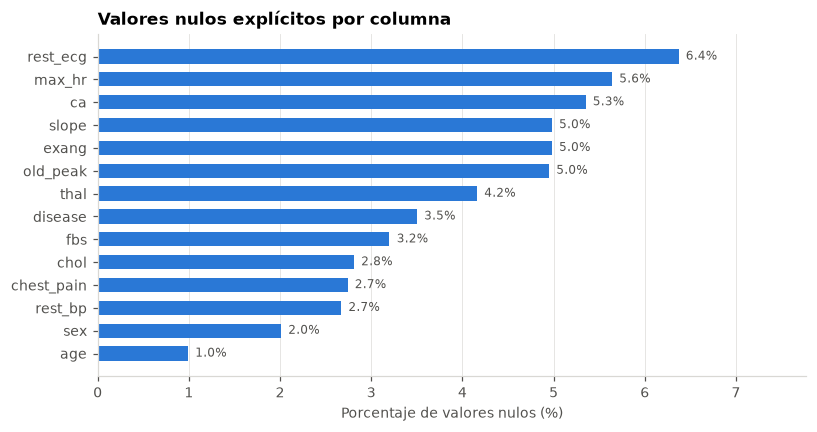

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 4))
d = nulos.sort_values("pct_nulos")
ax.barh(d.index, d["pct_nulos"], color=AZUL, height=0.62)
for y, v in zip(d.index, d["pct_nulos"]):
    ax.text(v + 0.08, y, f"{v:.1f}%", va="center", fontsize=8, color=GRIS_TXT)
ax.set_xlabel("Porcentaje de valores nulos (%)")
ax.set_title("Valores nulos explícitos por columna", loc="left")
ax.set_xlim(0, d["pct_nulos"].max() * 1.22)
ax.grid(axis="x", alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


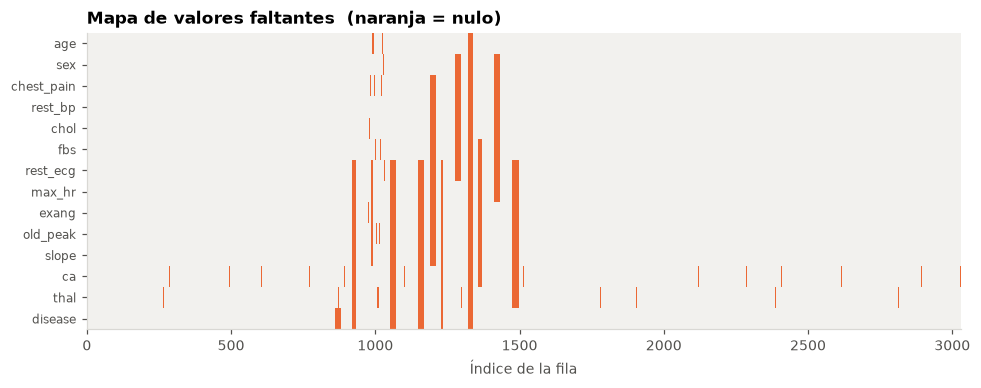

Filas sin ningún nulo: 2712
Filas con al menos un nulo: 318
Máx. de nulos en una misma fila: 14


In [15]:
# Mapa de calor: dónde se ubican los nulos dentro del archivo
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.imshow(
    df.isna().T.values,
    aspect="auto",
    cmap=mpl.colors.ListedColormap(["#f2f1ee", NARANJA]),
    interpolation="nearest",
)
ax.set_yticks(range(len(df.columns)))
ax.set_yticklabels(df.columns, fontsize=8)
ax.set_xlabel("Índice de la fila")
ax.set_title("Mapa de valores faltantes  (naranja = nulo)", loc="left")
ax.grid(False)
plt.tight_layout()
plt.show()

print("Filas sin ningún nulo:", int(df.notna().all(axis=1).sum()))
print("Filas con al menos un nulo:", int(df.isna().any(axis=1).sum()))
print("Máx. de nulos en una misma fila:", int(df.isna().sum(axis=1).max()))


## 2.4 Filas sin información

El resumen anterior muestra que hay filas con **14 nulos**, es decir, filas en las que *todas* las columnas están vacías. Conviene cuantificarlo.

In [16]:
por_fila = df.isna().sum(axis=1).value_counts().sort_index()
por_fila.name = "n_filas"
por_fila.index.name = "nulos_en_la_fila"
print(por_fila.to_string())

vacias_total = int((df.isna().sum(axis=1) == df.shape[1]).sum())
print(f"\nFilas completamente vacías: {vacias_total}")


nulos_en_la_fila
0     2712
1      119
2       10
5        2
6       27
7       57
8       67
9       19
10       2
14      15

Filas completamente vacías: 15


Aparecen **15 filas totalmente vacías**: no aportan ni un solo dato, ni siquiera la variable objetivo. A diferencia de los duplicados, aquí la decisión es inequívoca — un registro sin ningún valor no es un paciente, es una fila espuria del archivo — así que se eliminan.

También se observa un grupo intermedio de filas con entre 6 y 10 campos faltantes. Se conservan: aún contienen información utilizable y descartarlas sería una decisión de modelado, no de limpieza.

In [17]:
antes_n = len(df)
df = df[~df.isna().all(axis=1)].reset_index(drop=True)
print(f"Filas eliminadas (completamente vacías): {antes_n - len(df)}")
print(f"Filas restantes: {len(df):,}")


Filas eliminadas (completamente vacías): 15
Filas restantes: 3,015


## 2.5 ¿Los nulos siguen algún patrón?

El mapa de calor anterior muestra algo que las tablas de porcentajes ocultaban: los nulos **no están repartidos de forma uniforme**, sino concentrados en una franja contigua del archivo. Lo cuantificamos.

In [18]:
mask = crudo.eq("")
por_bloque = (
    mask.sum(axis=1)
    .groupby(pd.cut(np.arange(len(crudo)), bins=range(0, len(crudo) + 250, 250)))
    .sum()
)
por_bloque.index.name = "bloque_de_filas"
por_bloque.name = "n_nulos"
print(por_bloque.to_string())

en_franja = int(mask.iloc[850:1500].values.sum())
print(
    f"\nNulos dentro de las filas 850-1500 : {en_franja:,} de {int(mask.values.sum()):,} "
    f"({en_franja / mask.values.sum():.1%} del total)"
)


bloque_de_filas
(0, 250]          3
(250, 500]        6
(500, 750]        4
(750, 1000]     211
(1000, 1250]    647
(1250, 1500]    745
(1500, 1750]      4
(1750, 2000]      5
(2000, 2250]      5
(2250, 2500]      5
(2500, 2750]      6
(2750, 3000]      4
(3000, 3250]      2

Nulos dentro de las filas 850-1500 : 1,601 de 1,647 (97.2% del total)


**Hallazgo:** el **97%** de los valores faltantes se concentra en el tramo de filas ~850 a ~1500, mientras que el resto del archivo apenas tiene nulos aislados.

Esto refuerza la hipótesis planteada con los duplicados: el archivo es una réplica del dataset original de Cleveland a la que se le **inyectó ruido de forma deliberada en un segmento concreto** (probablemente como ejercicio de limpieza), y no el resultado de un fallo aleatorio de captura clínica.

La implicación práctica es importante: como el mecanismo de los nulos es artificial y no depende del valor real de la variable, los faltantes son **MCAR** (*missing completely at random*). Descartar o imputar esas filas no introduciría sesgo — a diferencia de lo que ocurriría si, por ejemplo, faltara el colesterol precisamente en los pacientes más graves.

---
# 3. Conversión al tipo correcto y corrección de los datos

Estrategia por familia de variable:

| Familia | Columnas | Tipo destino | Tratamiento |
|---|---|---|---|
| Numérica entera | `age`, `rest_bp`, `chol`, `max_hr`, `ca` | `Int16` / `Int8` | `to_numeric(errors="coerce")`: lo no convertible pasa a nulo |
| Numérica decimal | `old_peak` | `Float64` | Idem |
| Booleana | `fbs`, `exang`, `disease` | `boolean` | `1/0` → `True/False`; el resto a nulo |
| Categórica nominal | `sex`, `chest_pain`, `rest_ecg`, `thal` | `category` | Normalización de etiquetas + lista blanca de categorías válidas |
| Categórica ordinal | `slope` | `category` ordenada | Se preserva el orden clínico ascendente < plana < descendente |

La clave del enfoque es `errors="coerce"` y las **listas blancas**: cualquier valor que no pertenezca al dominio de la variable se convierte automáticamente al mismo marcador nulo `pd.NA` definido en la sección 2. Así, tras la conversión, cada columna queda con un tipo de dato uniforme por construcción.

## 3.1 Variables numéricas

In [19]:
df["age"] = pd.to_numeric(df["age"], errors="coerce").astype("Int16")
df["rest_bp"] = pd.to_numeric(df["rest_bp"], errors="coerce").astype("Int16")
df["chol"] = pd.to_numeric(df["chol"], errors="coerce").astype("Int16")
df["max_hr"] = pd.to_numeric(df["max_hr"], errors="coerce").astype("Int16")
df["old_peak"] = pd.to_numeric(df["old_peak"], errors="coerce").astype("Float64")

# 'ca' viene escrito como decimal ("0.0", "3.0") pero es un conteo de vasos: entero 0-3
df["ca"] = pd.to_numeric(df["ca"], errors="coerce").astype("Float64").astype("Int8")

df[["age", "rest_bp", "chol", "max_hr", "old_peak", "ca"]].dtypes


age           Int16
rest_bp       Int16
chol          Int16
max_hr        Int16
old_peak    Float64
ca             Int8
dtype: object

### Validación de rangos: ¿los valores numéricos son clínicamente plausibles?

Convertir a número no garantiza que el dato sea correcto. Contrastamos cada columna contra un rango fisiológicamente admisible.

In [20]:
RANGOS_VALIDOS = {
    "age": (18, 110, "años"),
    "rest_bp": (60, 260, "mm Hg"),
    "chol": (80, 700, "mg/dl"),
    "max_hr": (50, 240, "lpm"),
    "old_peak": (0, 10, "depresión ST"),
    "ca": (0, 3, "vasos"),
}

filas = []
for col, (lo, hi, unidad) in RANGOS_VALIDOS.items():
    s = df[col].dropna()
    fuera = int(((s < lo) | (s > hi)).sum())
    filas.append(
        {
            "columna": col,
            "unidad": unidad,
            "rango_admisible": f"[{lo}, {hi}]",
            "min_observado": s.min(),
            "max_observado": s.max(),
            "fuera_de_rango": fuera,
        }
    )

validacion = pd.DataFrame(filas)
validacion


,columna,unidad,rango_admisible,min_observado,max_observado,fuera_de_rango
0,age,años,"[18, 110]",29.0,77.0,0
1,rest_bp,mm Hg,"[60, 260]",94.0,200.0,0
2,chol,mg/dl,"[80, 700]",126.0,564.0,0
3,max_hr,lpm,"[50, 240]",71.0,202.0,0
4,old_peak,depresión ST,"[0, 10]",0.0,6.2,0
5,ca,vasos,"[0, 3]",0.0,3.0,0


Todos los valores numéricos caen dentro de rangos clínicamente plausibles: **no hay que corregir ni recortar ningún valor extremo**. El único problema de estas columnas era el texto basura, que ya se convirtió en nulo.

Aun así, comprobamos si hay outliers estadísticos que convenga tener presentes en el análisis posterior.

In [21]:
num_cols = ["age", "rest_bp", "chol", "max_hr", "old_peak"]
resumen_out = []
for col in num_cols:
    s = df[col].dropna().astype(float)
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    resumen_out.append(
        {
            "columna": col,
            "Q1": round(q1, 2),
            "mediana": round(s.median(), 2),
            "Q3": round(q3, 2),
            "limite_inf": round(lo, 2),
            "limite_sup": round(hi, 2),
            "n_outliers": int(((s < lo) | (s > hi)).sum()),
            "pct_outliers": round(((s < lo) | (s > hi)).mean() * 100, 2),
        }
    )
pd.DataFrame(resumen_out)


,columna,Q1,mediana,Q3,limite_inf,limite_sup,n_outliers,pct_outliers
0,age,48.0,56.0,61.0,28.5,80.5,0,0.00
1,rest_bp,120.0,130.0,140.0,90.0,170.0,86,2.92
2,chol,211.0,241.0,275.0,115.0,371.0,48,1.63
3,max_hr,133.0,153.0,166.0,83.5,215.5,9,0.31
4,old_peak,0.0,0.8,1.6,-2.4,4.0,48,1.67


## 3.2 Variables booleanas

In [22]:
MAPA_BOOL = {
    "1": True,
    "0": False,
    "true": True,
    "false": False,
    "si": True,
    "sí": True,
    "no": False,
    "yes": True,
}

for col in ["fbs", "exang", "disease"]:
    df[col] = df[col].str.lower().map(MAPA_BOOL).astype("boolean")

df[["fbs", "exang", "disease"]].apply(lambda s: s.value_counts(dropna=False))


,fbs,exang,disease
False,2498,1929,1576
True,435,948,1343
<NA>,82,138,96


> **Nota sobre `disease`:** es la variable objetivo. Convertirla a `boolean` en lugar de dejarla como `0/1` entero evita que un modelo o un `describe()` la traten por error como una magnitud numérica continua.

## 3.3 Variables categóricas

In [23]:
# Normalización de etiquetas: minúsculas, sin espacios sobrantes, y forma canónica legible
CANONICO = {
    "sex": {"male": "Male", "female": "Female"},
    "chest_pain": {
        "typical": "typical",
        "nontypical": "nontypical",
        "nonanginal": "nonanginal",
        "asymptomatic": "asymptomatic",
    },
    "rest_ecg": {
        "normal": "normal",
        "st-t wave abnormality": "ST-T wave abnormality",
        "left ventricular hypertrophy": "left ventricular hypertrophy",
    },
    "thal": {"normal": "normal", "fixed": "fixed", "reversable": "reversable"},
}

for col, mapa in CANONICO.items():
    # .map() deja como nulo todo lo que no esté en la lista blanca -> los valores basura caen aquí
    df[col] = df[col].str.lower().map(mapa).astype("category")

# 'slope' es ordinal: se preserva el orden clínico
MAPA_SLOPE = {"1": "ascendente", "2": "plana", "3": "descendente"}
df["slope"] = pd.Categorical(
    df["slope"].map(MAPA_SLOPE),
    categories=["ascendente", "plana", "descendente"],
    ordered=True,
)

for col in ["sex", "chest_pain", "rest_ecg", "thal", "slope"]:
    print(
        f"{col:<12} -> {list(df[col].cat.categories)}"
        f"{'  (ordenada)' if df[col].cat.ordered else ''}"
    )


sex          -> ['Female', 'Male']
chest_pain   -> ['asymptomatic', 'nonanginal', 'nontypical', 'typical']
rest_ecg     -> ['ST-T wave abnormality', 'left ventricular hypertrophy', 'normal']
thal         -> ['fixed', 'normal', 'reversable']
slope        -> ['ascendente', 'plana', 'descendente']  (ordenada)


Se resolvió también un problema silencioso: la etiqueta `'left ventricular hypertrophy '` venía con un **espacio final** en el archivo original. Sin normalizar, pandas la habría tratado como una categoría distinta de `'left ventricular hypertrophy'`, inflando artificialmente la cardinalidad.

## 3.4 ¿Hay columnas de baja calidad que convenga eliminar?

La guía de referencia contempla descartar columnas cuya calidad las haga inservibles. Aplicamos
tres criterios objetivos en lugar de decidirlo a ojo:

1. **Exceso de nulos** — más del 40% de valores faltantes.
2. **Varianza nula** — una única categoría o valor, que no aporta información.
3. **Cardinalidad casi única** — más del 95% de valores distintos, propio de un identificador.

In [24]:
filas = []
for col in df.columns:
    s = df[col]
    pct_nulos = s.isna().mean() * 100
    n_uni = s.nunique(dropna=True)
    pct_uni = n_uni / max(s.notna().sum(), 1) * 100

    motivos = []
    if pct_nulos > 40:
        motivos.append("exceso de nulos")
    if n_uni <= 1:
        motivos.append("varianza nula")
    if pct_uni > 95:
        motivos.append("parece identificador")

    filas.append(
        {
            "columna": col,
            "pct_nulos": round(pct_nulos, 2),
            "valores_unicos": n_uni,
            "pct_unicos": round(pct_uni, 2),
            "eliminar": "SÍ - " + ", ".join(motivos) if motivos else "no",
        }
    )

calidad = pd.DataFrame(filas)
calidad


,columna,pct_nulos,valores_unicos,pct_unicos,eliminar
0,age,0.56,41,1.37,no
1,sex,1.63,2,0.07,no
2,chest_pain,2.35,4,0.14,no
3,rest_bp,2.26,50,1.70,no
4,chol,2.39,152,5.16,no
5,fbs,2.72,2,0.07,no
6,rest_ecg,6.07,3,0.11,no
7,max_hr,5.21,91,3.18,no
8,exang,4.58,2,0.07,no
9,old_peak,4.54,40,1.39,no


In [25]:
a_eliminar = calidad.loc[calidad["eliminar"] != "no", "columna"].tolist()

if a_eliminar:
    df = df.drop(columns=a_eliminar)
    print("Columnas eliminadas:", a_eliminar)
else:
    print("Ninguna columna cumple los criterios de eliminación.")
    print(f"Nulos máximos en una columna: {df.isna().mean().max():.1%}")
    print(f"Se conservan las {df.shape[1]} columnas.")


Ninguna columna cumple los criterios de eliminación.
Nulos máximos en una columna: 6.1%
Se conservan las 14 columnas.


**Resultado:** ninguna columna se elimina. La peor ronda el 6% de nulos, todas tienen más de una
categoría y ninguna se comporta como identificador. Cada una de las 14 variables tiene además
significado clínico documentado, así que descartarlas costaría información sin ganar nada.

La celda de eliminación queda escrita y activa: si el criterio cambia o el dataset se actualiza,
se aplica sola sin tocar el código.

## 3.5 Nota sobre el backend de tipos

La guía de referencia sugiere `dtype_backend="pyarrow"`. Aquí se usan los **tipos nullable nativos
de pandas** (`Int16`, `boolean`, `category`). La diferencia práctica:

| | Tipos nullable de pandas | Backend pyarrow |
|---|---|---|
| Marcador de nulo | `pd.NA` | `pd.NA` |
| Categórica **ordenada** | Sí (`slope` conserva su orden) | Soporte más limitado |
| Compatibilidad con scikit-learn y statsmodels | Amplia | Aún irregular |
| Memoria en columnas de texto | Mayor | Menor |

Se eligieron los tipos de pandas porque `slope` es ordinal y su orden clínico debe preservarse, y
porque el siguiente paso del proyecto es modelar. Al guardar en Parquet el resultado es equivalente:
Arrow es el formato subyacente en ambos casos. Para leer el dataset con backend pyarrow basta con:

```python
pd.read_parquet(RUTA_PARQUET, dtype_backend="pyarrow")
```

---

---
# 4. Verificación del dataset limpio

## 4.1 Tipos finales: ¿es cada columna uniforme?

In [26]:
verificacion = pd.DataFrame(
    {
        "tipo_original": crudo.dtypes.astype(str),
        "tipo_final": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "pct_nulos": (df.isna().mean() * 100).round(2),
        "n_categorias_o_unicos": df.nunique(),
    }
)
verificacion


,tipo_original,tipo_final,n_nulos,pct_nulos,n_categorias_o_unicos
age,str,Int16,17,0.56,41
sex,str,category,49,1.63,2
chest_pain,str,category,71,2.35,4
rest_bp,str,Int16,68,2.26,50
chol,str,Int16,72,2.39,152
fbs,str,boolean,82,2.72,2
rest_ecg,str,category,183,6.07,3
max_hr,str,Int16,157,5.21,91
exang,str,boolean,138,4.58,2
old_peak,str,Float64,137,4.54,40


In [27]:
# Comprobación programática de que no queda ningún tipo 'object' ni valor mixto
assert not (df.dtypes == "object").any(), "Todavía hay columnas de tipo object"

for col in df.columns:
    tipos = df[col].dropna().map(type).unique()
    assert len(tipos) == 1, f"La columna {col} contiene tipos mixtos: {tipos}"

print("✔ Ninguna columna quedó como 'object'")
print("✔ Cada columna contiene un único tipo de dato Python")
print("✔ Todos los nulos se representan con el mismo marcador (pd.NA)")
print(
    f"\nMemoria: {crudo.memory_usage(deep=True).sum() / 1024:,.0f} KB (crudo)"
    f"  ->  {df.memory_usage(deep=True).sum() / 1024:,.0f} KB (limpio)"
)


✔ Ninguna columna quedó como 'object'
✔ Cada columna contiene un único tipo de dato Python
✔ Todos los nulos se representan con el mismo marcador (pd.NA)

Memoria: 505 KB (crudo)  ->  101 KB (limpio)


## 4.2 Nulos finales: explícitos + los recuperados de valores basura

In [28]:
# Se compara contra el crudo excluyendo las 15 filas vacías eliminadas, para que ambas cifras
# se refieran al mismo conjunto de filas.
crudo_comp = crudo[
    ~crudo.apply(lambda s: s.str.strip().str.lower().isin(MARCADORES_NULOS)).all(axis=1)
]

comparativa = pd.DataFrame(
    {
        "nulos_explicitos": crudo_comp.apply(
            lambda s: s.str.strip().str.lower().isin(MARCADORES_NULOS).sum()
        ),
        "nulos_totales_final": df.isna().sum(),
    }
)
comparativa["por_valor_basura"] = (
    comparativa["nulos_totales_final"] - comparativa["nulos_explicitos"]
)
comparativa["pct_final"] = (comparativa["nulos_totales_final"] / len(df) * 100).round(2)
comparativa


,nulos_explicitos,nulos_totales_final,por_valor_basura,pct_final
age,15,17,2,0.56
sex,46,49,3,1.63
chest_pain,68,71,3,2.35
rest_bp,66,68,2,2.26
chol,70,72,2,2.39
fbs,82,82,0,2.72
rest_ecg,178,183,5,6.07
max_hr,156,157,1,5.21
exang,136,138,2,4.58
old_peak,135,137,2,4.54


## 4.3 Estadísticas descriptivas del dataset limpio

In [29]:
df.describe(include="number").round(2)


,age,rest_bp,chol,max_hr,old_peak,ca
count,2998.0,2947.0,2943.0,2858.0,2878.0,2867.0
mean,54.46,131.62,246.72,149.56,1.04,0.67
std,9.02,17.57,51.6,22.88,1.16,0.94
min,29.0,94.0,126.0,71.0,0.0,0.0
25%,48.0,120.0,211.0,133.0,0.0,0.0
50%,56.0,130.0,241.0,153.0,0.8,0.0
75%,61.0,140.0,275.0,166.0,1.6,1.0
max,77.0,200.0,564.0,202.0,6.2,3.0


In [30]:
df.describe(include=["category", "boolean"])


,sex,chest_pain,fbs,rest_ecg,exang,slope,thal,disease
count,2966,2944,2933,2832,2877,2878,2900,2919
unique,2,4,2,3,2,3,3,2
top,Male,asymptomatic,False,normal,False,ascendente,normal,False
freq,2017,1394,2498,1409,1929,1353,1599,1576


## 4.4 Exploración visual del resultado

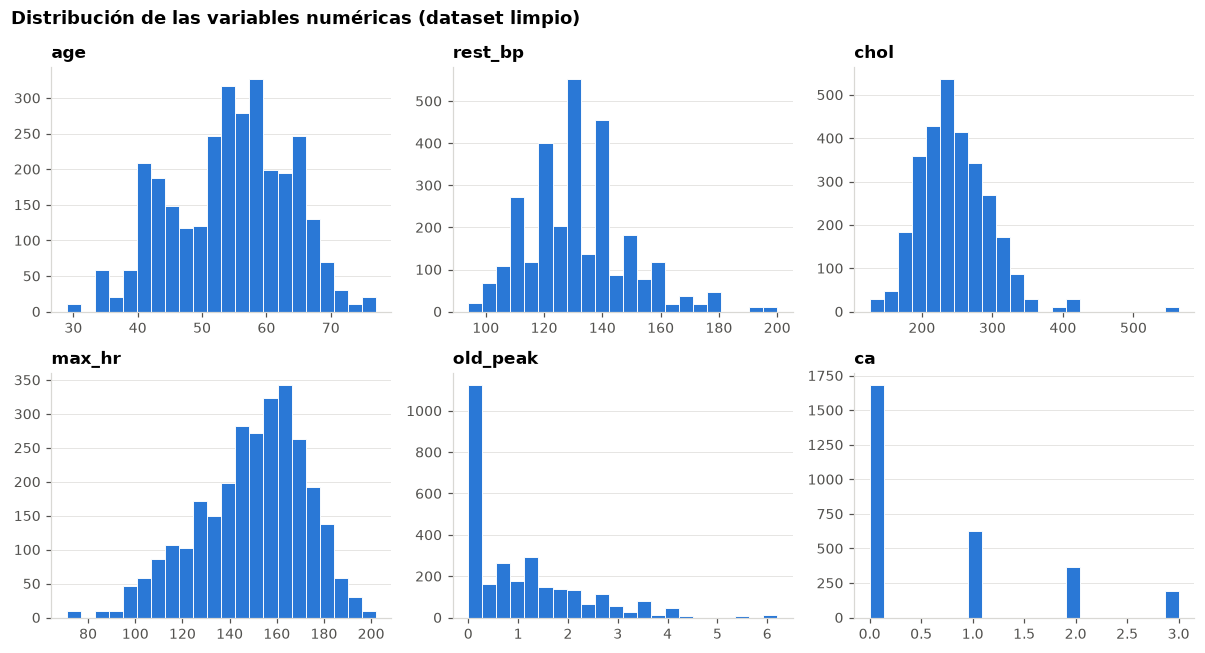

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6))
for ax, col in zip(
    axes.ravel(), ["age", "rest_bp", "chol", "max_hr", "old_peak", "ca"]
):
    s = df[col].dropna().astype(float)
    ax.hist(s, bins=22, color=AZUL, edgecolor="white", linewidth=0.6)
    ax.set_title(col, loc="left")
    ax.grid(axis="y", alpha=0.7)
    ax.set_axisbelow(True)
fig.suptitle(
    "Distribución de las variables numéricas (dataset limpio)",
    x=0.01,
    ha="left",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()


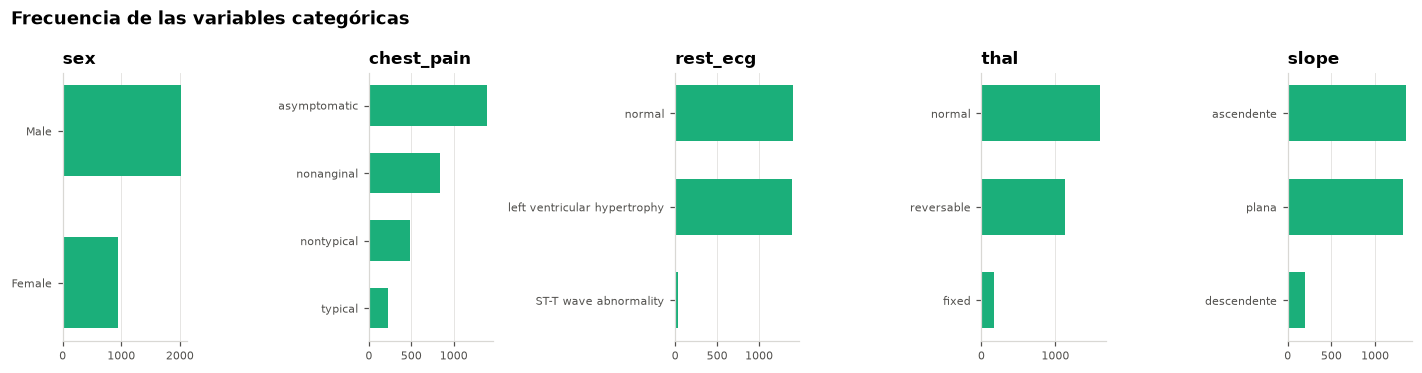

In [32]:
cats = ["sex", "chest_pain", "rest_ecg", "thal", "slope"]
fig, axes = plt.subplots(1, 5, figsize=(13, 3.4))
for ax, col in zip(axes, cats):
    vc = df[col].value_counts().sort_values()
    ax.barh([str(i) for i in vc.index], vc.values, color=VERDE, height=0.6)
    ax.set_title(col, loc="left")
    ax.tick_params(labelsize=7)
    ax.grid(axis="x", alpha=0.7)
    ax.set_axisbelow(True)
fig.suptitle(
    "Frecuencia de las variables categóricas",
    x=0.01,
    ha="left",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()


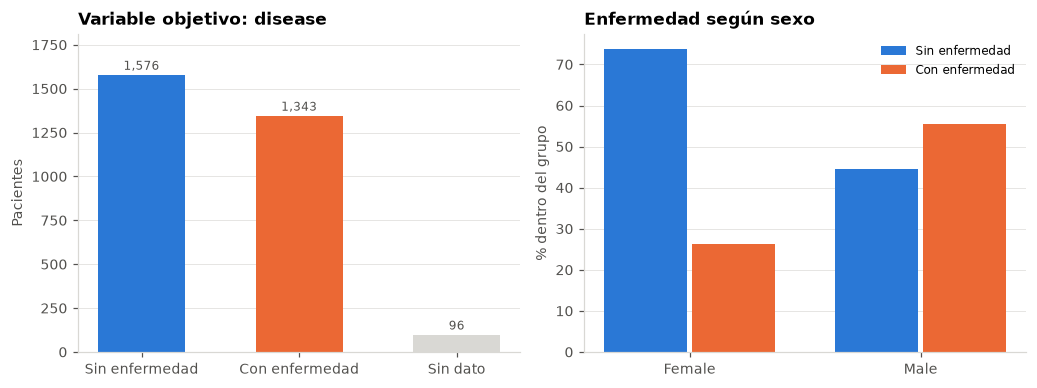

In [33]:
# Variable objetivo y su relación con el sexo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.6))

conteo = {
    "Sin enfermedad": int(df["disease"].eq(False).sum()),
    "Con enfermedad": int(df["disease"].eq(True).sum()),
    "Sin dato": int(df["disease"].isna().sum()),
}
ax1.bar(
    list(conteo), list(conteo.values()), color=[AZUL, NARANJA, GRIS_SUAVE], width=0.55
)
for x, v in enumerate(conteo.values()):
    ax1.text(
        x,
        v + max(conteo.values()) * 0.02,
        f"{v:,}",
        ha="center",
        fontsize=8,
        color=GRIS_TXT,
    )
ax1.set_ylim(0, max(conteo.values()) * 1.15)
ax1.set_title("Variable objetivo: disease", loc="left")
ax1.set_ylabel("Pacientes")
ax1.grid(axis="y", alpha=0.7)
ax1.set_axisbelow(True)

tab = pd.crosstab(df["sex"], df["disease"], normalize="index") * 100
x = np.arange(len(tab.index))
ax2.bar(x - 0.19, tab[False], width=0.36, color=AZUL, label="Sin enfermedad")
ax2.bar(x + 0.19, tab[True], width=0.36, color=NARANJA, label="Con enfermedad")
ax2.set_xticks(x)
ax2.set_xticklabels(tab.index)
ax2.set_ylabel("% dentro del grupo")
ax2.set_title("Enfermedad según sexo", loc="left")
ax2.legend(frameon=False, fontsize=8)
ax2.grid(axis="y", alpha=0.7)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()


---
# 5. Almacenamiento del dataset final en `.parquet`

Parquet es el formato adecuado para cerrar esta etapa porque, a diferencia del CSV:

- **Conserva el esquema.** Los tipos (`Int16`, `boolean`, `category`, categórica ordenada) se guardan dentro del archivo, así que al releer no hay que repetir la limpieza ni volver a inferir nada.
- **Distingue el nulo de forma nativa**, mediante un mapa de bits independiente de los datos. Un CSV solo puede escribir una cadena vacía, que es justamente la ambigüedad que corregimos en la sección 2.
- **Es columnar y comprimido**, lo que reduce el tamaño en disco y permite leer solo las columnas necesarias.

In [34]:
import os

df.to_parquet(RUTA_PARQUET, engine="pyarrow", compression="snappy", index=False)

kb_csv = os.path.getsize(RUTA_CSV) / 1024
kb_pq = os.path.getsize(RUTA_PARQUET) / 1024
print(f"CSV original : {kb_csv:8,.1f} KB")
print(f"Parquet final: {kb_pq:8,.1f} KB   (reducción del {(1 - kb_pq / kb_csv):.1%})")


CSV original :    215.0 KB
Parquet final:     19.1 KB   (reducción del 91.1%)


In [35]:
verif = pd.read_parquet(RUTA_PARQUET)

print("Tipos tras releer el archivo Parquet:")
print(verif.dtypes.to_string())

assert verif.shape == df.shape
assert (verif.dtypes.astype(str) == df.dtypes.astype(str)).all(), (
    "El esquema no coincide"
)
assert int(verif.isna().sum().sum()) == int(df.isna().sum().sum()), (
    "Los nulos no coinciden"
)
assert verif["slope"].cat.ordered, "Se perdió el orden de la categórica ordinal"

print("\n✔ Dimensiones idénticas")
print("✔ Todos los tipos se conservaron exactamente")
print("✔ Los valores nulos se conservaron")
print("✔ El orden de la variable categórica ordinal 'slope' se conservó")
verif.head()


Tipos tras releer el archivo Parquet:
age              Int16
sex           category
chest_pain    category
rest_bp          Int16
chol             Int16
fbs            boolean
rest_ecg      category
max_hr           Int16
exang          boolean
old_peak       Float64
slope         category
ca                Int8
thal          category
disease        boolean

✔ Dimensiones idénticas
✔ Todos los tipos se conservaron exactamente
✔ Los valores nulos se conservaron
✔ El orden de la variable categórica ordinal 'slope' se conservó


,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
0,63,Male,typical,145,233,True,left ventricular hypertrophy,150,False,2.3,descendente,0,fixed,False
1,67,Male,asymptomatic,160,286,False,left ventricular hypertrophy,108,True,1.5,plana,3,normal,True
2,67,Male,asymptomatic,120,229,False,left ventricular hypertrophy,129,True,2.6,plana,2,reversable,True
3,37,Male,nonanginal,130,250,False,normal,187,False,3.5,descendente,0,normal,False
4,41,Female,nontypical,130,204,False,left ventricular hypertrophy,172,False,1.4,ascendente,0,normal,False


## 5.2 Opcional: versión deduplicada

Si el análisis posterior requiere trabajar solo con registros únicos, basta con ejecutar la celda siguiente. Se deja como paso separado y explícito para no alterar el entregable principal.

In [36]:
# df_unico = df.drop_duplicates().reset_index(drop=True)
# df_unico.to_parquet(RUTA_CSV.parent / "corazon_limpio_sin_duplicados.parquet",
#                     engine="pyarrow", compression="snappy", index=False)
# print("Filas tras deduplicar:", len(df_unico))


---
# 6. Conclusiones

**Estado inicial.** El archivo tenía 3.030 filas y 14 columnas, todas leídas como texto. Ninguna columna tenía un tipo de dato uniforme y pandas no reconocía ni un solo valor nulo.

**Problemas detectados y resueltos**

| Problema | Alcance | Solución aplicada |
|---|---|---|
| Nulos escritos como cadena vacía `""` | 1.647 celdas, en las 14 columnas | Unificados a `pd.NA` |
| Filas completamente vacías | 15 filas | Eliminadas (no aportan ningún dato) |
| Texto basura en columnas numéricas (`wety`, `afd`, `sdg`...) | 10 celdas | `to_numeric(errors="coerce")` → `pd.NA` |
| Ruido y códigos fuera de dominio en columnas categóricas y booleanas (`2345`, `87654`, `fsdg`, `f`...) | 23 celdas | Lista blanca de categorías → `pd.NA` |
| Etiqueta con espacio final (`'left ventricular hypertrophy '`) | Toda la columna `rest_ecg` | Normalización de texto antes de categorizar |
| Todas las columnas como `object` | 14 columnas | Tipado explícito con tipos *nullable* |
| Filas duplicadas exactas | 2.462 (81%) | Documentado; deduplicación disponible como paso opcional |

**Estado final**

- 3.015 filas × 14 columnas.
- Un único marcador de nulo (`pd.NA`) en todo el dataset, coherente entre columnas numéricas, booleanas y categóricas.
- 6 columnas numéricas (`Int16`/`Int8`/`Float64`), 3 booleanas (`boolean`), 5 categóricas (`category`, una de ellas ordenada).
- Todos los valores numéricos verificados dentro de rangos clínicamente plausibles: no hubo que corregir ni recortar ningún valor.
- Dataset almacenado en `corazon_limpio.parquet`, con el esquema y los nulos verificados tras la relectura.

**Nota sobre imputación.** Los nulos se dejan como tales de forma deliberada: la consigna pide *unificar* su representación, no rellenarlos. Cualquier imputación (mediana, moda, KNN) es una decisión de modelado que corresponde a la siguiente etapa y que, además, debe ajustarse solo sobre el conjunto de entrenamiento para no filtrar información.